# Introduction #

The English Premier League is one of the most financially powerful sports competitions in the world, with clubs collectively spending over £3 billion annually on player wages. Yet despite this enormous financial commitment, salary allocation across players remains deeply uneven — and often difficult to justify on performance alone. Some players command wages that far exceed their on-pitch contributions, while others who consistently deliver elite statistics remain comparatively underpaid. This disconnect raises a fundamental question at the heart of sports analytics and labor economics: are Premier League clubs efficiently pricing their talent?

This project, Soccer Wage Efficiency and Mispricing, aims to answer that question through a data-driven lens. By integrating detailed player performance statistics from FBref with contract and salary data from Capology, we construct a comprehensive dataset spanning over 550 Premier League players across 39 combined features. Using this merged dataset, we build a machine learning salary prediction model — segmented by player position — to estimate what a player should earn based on their measurable contributions. Players whose actual wages deviate significantly from model predictions are flagged as potentially overvalued or undervalued, providing clubs, analysts, and fans with an objective framework for evaluating wage efficiency.

The motivation behind this project is both analytical and personal. As fans of the sport, we've long debated whether a player's paycheck reflects their true value or whether factors like marketability, name recognition, and injury history distort what clubs are willing to pay. We hypothesize that salary is driven by a combination of performance metrics, brand equity, and positional scarcity — and that OLS regression paired with SHAP-based explainability will surface which factors clubs weight most heavily, and where mispricing tends to occur. Ultimately, this analysis serves as a practical tool for clubs seeking to optimize squad investment and for analysts interested in the economics of elite football.

### Changes from Proposal ###
Since the proposal, we have decided to switch from using FBref to using SofaScore for statistics. This change was made since Sofascore had a much more vast collection of stats, while FBref only had basic stats that only applied to offensive players (goals and assists). The SofaScore data had 100 more columns that show stats for all different positions (offensive, defensive, and goalies), which will help us gauge the performance of different types of players.

It was also mentioned that we were going to use the previous season's stats since they were more complete compared to the current season that ongoing. We decided to include the previous 5 seasons to make our data more robust and possibly show changes between seasons.

# Data Retrieval, Cleaning, and Transformation #

### ScraperFC ###
SCraperFC is a Python Library made a couple of years ago that makes extracting data from popular football stat websites easy and free.

Usually you would install ScraperFC through PIP but my poor computer has like 3 instances of python on it and gets confused. I had to do this to make sure it installed properly.

In [3]:
import sys
import subprocess

# This identifies the exact python.exe your notebook is currently using
python = sys.executable

# This runs the install command via the system
subprocess.check_call([python, '-m', 'pip', 'install', 'ScraperFC'])

print("Installation successful!")

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installi

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ScraperFC as sfc
import time
import difflib

### Capology ###
Capology is a website that provides comprehensive estimates of professional football player salaries and club financial data. We are going to use it to gather the player salary data.

Data is taken directedly from the html files through ScraperFC and turned into a dataframe. Unneccessary or redundant columns (country of origin, weekly pay, etc.) are removed, the yearly pay column is converted from a string (since it is taken from an html file) to a double for calculations, and the column labels are renamed for clairity.

Data is taken from the 5 previous seasons (to get a wide variety of data but avoid having to add inflation calculations). Each season is processed separatedly, has a season column added, and then added to one large final dataframe.

In [5]:
# Import functions
from scraper_fuctions import scrape_capology_multiple_seasons

# Define seasons to scrape
seasons_to_scrape = ['2024-25', '2023-24', '2022-23', '2021-22', '2020-21']

# Run scraper
capology_df = scrape_capology_multiple_seasons(seasons = seasons_to_scrape, sleep_time = 10)

# Display the results
if capology_df is not None:
    display(capology_df.head())
    print(f"\nTotal entries in dataset: {len(capology_df)}")

Scraping data for the 2024-25 season...
Changed currency to eur.
  -> Uh oh, something went wrong with 2024-25: 'Salary (EUR)'
  -> Sleeping for 10 seconds...

Scraping data for the 2023-24 season...
Changed currency to eur.
  -> Uh oh, something went wrong with 2023-24: 'Salary (EUR)'
  -> Sleeping for 10 seconds...

Scraping data for the 2022-23 season...
Changed currency to eur.
  -> Uh oh, something went wrong with 2022-23: 'Salary (EUR)'
  -> Sleeping for 10 seconds...

Scraping data for the 2021-22 season...
Changed currency to eur.
  -> Uh oh, something went wrong with 2021-22: 'Salary (EUR)'
  -> Sleeping for 10 seconds...

Scraping data for the 2020-21 season...
Changed currency to eur.
  -> Uh oh, something went wrong with 2020-21: 'Salary (EUR)'
  -> Sleeping for 10 seconds...

No data was successfully scraped.


### SofaScore ###
SofaScore is a premier live score and sports analytics platform that provides real-time data, detailed statistics, and unique player ratings. We are going to use it to gather specific player data, it has 110 unique stats.

Data is taken from the SofaScore API through ScraperFC and turned into a dataframe. Unneccessary or redundant columns (team, player_id, etc.) are removed and its season is reformated to match the syntax that Capology used (to make merging easier later).

Data is taken from the 5 previous seasons (to match Capology data). Each season is processed separatedly, has a season column added, and then added to one large final dataframe. After all seasons have combined, any columns with null values are removed (to account for different stats being recorded each season and prevent conclusion that ignore a season).

In [6]:
# Import functions
from scraper_fuctions import scrape_sofascore_multiple_seasons

# Run scraper
sofa_df = scrape_sofascore_multiple_seasons(seasons = seasons_to_scrape, sleep_time = 10)

# Display the results
if sofa_df is not None:
    display(sofa_df[['Season', 'Player', 'rating']].head())
    print(f"\nTotal entries in dataset: {len(sofa_df)}")

Scraping Sofascore data for the 2024-25 season (API format: 24/25)...
Running
  -> Success! 562 players scraped. Columns: 111
  -> Sleeping for 10 seconds...

Scraping Sofascore data for the 2023-24 season (API format: 23/24)...
  -> Success! 570 players scraped. Columns: 112
  -> Sleeping for 10 seconds...

Scraping Sofascore data for the 2022-23 season (API format: 22/23)...
  -> Success! 554 players scraped. Columns: 110
  -> Sleeping for 10 seconds...

Scraping Sofascore data for the 2021-22 season (API format: 21/22)...
  -> Success! 538 players scraped. Columns: 107
  -> Sleeping for 10 seconds...

Scraping Sofascore data for the 2020-21 season (API format: 20/21)...
  -> Success! 524 players scraped. Columns: 106
  -> Sleeping for 10 seconds...

Scraping complete! Sofascore Master DataFrame created.


,Season,Player,rating
0,2024-25,Neto,7.85
1,2024-25,Mohamed Salah,7.78
2,2024-25,Cole Palmer,7.63
3,2024-25,Mark Travers,7.62
4,2024-25,Bruno Fernandes,7.62



Total entries in dataset: 2748


In [7]:
print(sofa_df.columns.tolist())

['Season', 'accurateChippedPasses', 'accurateCrosses', 'accurateCrossesPercentage', 'accurateFinalThirdPasses', 'accurateLongBalls', 'accurateLongBallsPercentage', 'accurateOppositionHalfPasses', 'accurateOwnHalfPasses', 'accuratePasses', 'accuratePassesPercentage', 'aerialDuelsWon', 'aerialDuelsWonPercentage', 'aerialLost', 'appearances', 'assists', 'attemptPenaltyMiss', 'attemptPenaltyPost', 'attemptPenaltyTarget', 'bigChancesCreated', 'bigChancesMissed', 'blockedShots', 'cleanSheet', 'clearances', 'countRating', 'crossesNotClaimed', 'directRedCards', 'dispossessed', 'dribbledPast', 'duelLost', 'errorLeadToGoal', 'errorLeadToShot', 'fouls', 'freeKickGoal', 'goalConversionPercentage', 'goals', 'goalsAssistsSum', 'goalsConceded', 'goalsConcededInsideTheBox', 'goalsConcededOutsideTheBox', 'goalsFromInsideTheBox', 'goalsFromOutsideTheBox', 'groundDuelsWon', 'groundDuelsWonPercentage', 'headedGoals', 'highClaims', 'hitWoodwork', 'inaccuratePasses', 'interceptions', 'keyPasses', 'leftFootG

### Merging the Dataframes ###
The two data frames are combined on player name and season.

Difflab is a python library that is used to match up the player names between the two different dataframe (to account for naming differeneces like accents or capitalization). Seasons titles are already normalized across the dataframes.

In [9]:
# Import merge function
from merge_functions import build_master_dataset

# Build the final dataset
combined_df = build_master_dataset(capology_df, sofa_df)

# Display the results
print(f"\nTotal Rows: {len(combined_df)}")
print(f"Total Columns: {len(combined_df.columns)}")
display(combined_df.head())

Standardizing Capology player names to match Sofascore...


TypeError: 'NoneType' object is not subscriptable

# Visualization and insights #

### Average Salary per Position by Season ###

In [10]:
from plotting_functions import plot_avg_salary_by_position
plot_avg_salary_by_position(combined_df)

NameError: name 'combined_df' is not defined

### Salary Distribution and Outliers by Position ###

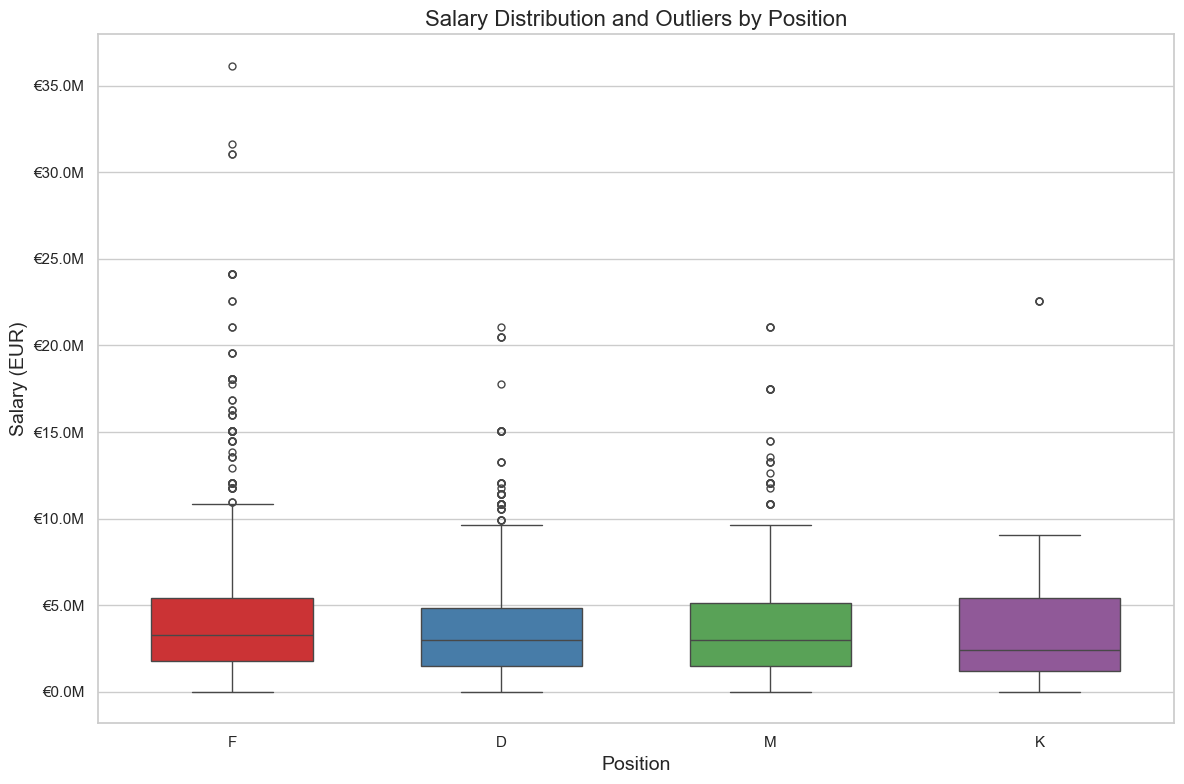

In [ ]:
%reload_ext autoreload
from plotting_functions import plot_salary_boxplot_by_position
plot_salary_boxplot_by_position(combined_df)

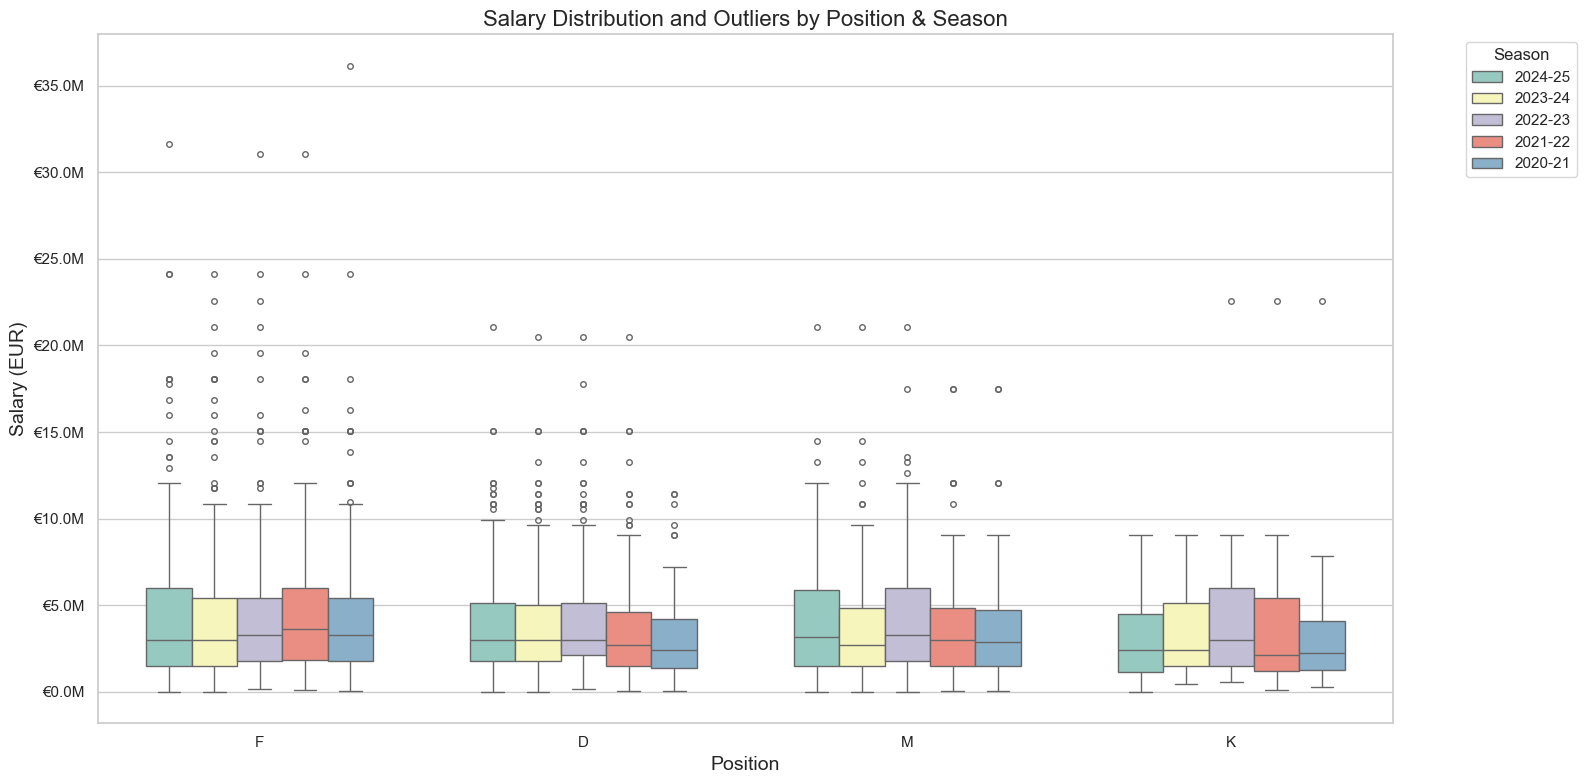

In [ ]:
from plotting_functions import plot_salary_boxplot_by_position_and_season
plot_salary_boxplot_by_position_and_season(combined_df)

### Salary vs Player Rating ###

Sofascore has its own internal rating system of players on a match-by-match basis that it averages for its total season statistics (which we are using). This was combined with their total goals to create a rough estimate of their performance that season.

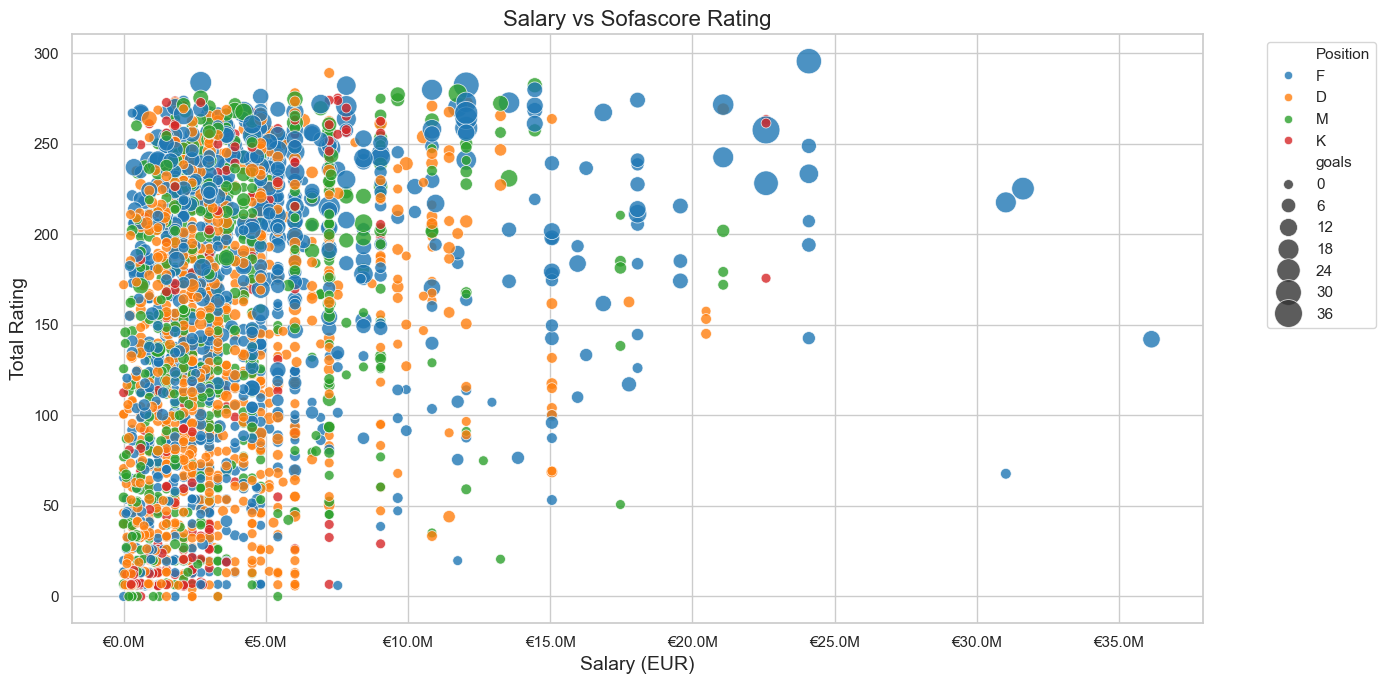

In [ ]:
from plotting_functions import plot_salary_vs_rating
plot_salary_vs_rating(combined_df)

#### Positions ####
- Forwards tend to dominate the high-salaries, with the highest average of shots taken. For a team to have better season performances having lots of goals will give you better results.
- Defenders and Midfielders are more so in the mid-range despite their ratings, showing that their performance doesn't correlate to higher salaries.

#### Salary vs Performance relationship ####
- Performance seems to inconsistent as there are clusters of high rated players with salaries that of lower rated players. This might suggest that many players are undervalued. Also the pay is heavily influenced by the position.

#### Shots vs Performance ####
- Bubble size represents totalShots. Larger bubbles are seen most buy higher rated strikers, which makes sense because players that shoot more given that they score a few times, contribute more to total rating.
- Some players with ratings around 150 but have larger bubbles may suggest that they have high activity but very inconsistent.

# Machine Learning #
The model splits the data at each step using entropy to find the split that best separates high and low earners. The max_depth=4 limit keeps the tree small so it doesn't just memorize the training data, but actually generalizes to new players. The model is trained on 80% of the players and tested on the remaining 20% to measure how well it predicts players it has never seen before.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

np.random.seed(418)
df = combined_df.copy()
# Keeping only players who played at least 5 full games
df = df[df['minutesPlayed'] >= 450].copy()

# Using log(salary) to prevent extreme skewness 
df['log_salary'] = np.log1p(df['Salary (EUR)'])

# Add age² to capture the career arc (peaks ~27, declines after)
#df['age_squared'] = df['Age'] ** 2

# Building per-90 stats to compare players fairly regardless of minutes played
stats = ['goals', 'assists', 'totalShots', 'keyPasses',
         'tackles', 'interceptions', 'saves', 'clearances']

for s in stats:
    df[f'{s}_per_90'] = df[s] / (df['minutesPlayed'] / 90)


# Picking features (x) and target(y) for the model

# One-hot encoding for position
df = pd.get_dummies(df, columns=['Position'], prefix='pos', drop_first=True)

# Features: per-90 stats + age + minutes + rating + position

features = (
    [f'{s}_per_90' for s in stats]
    + ['Age', 'minutesPlayed', 'rating']
    + [c for c in df.columns if c.startswith('pos_')]
)
# Drop rows with missing values
df_model = df.dropna(subset=features + ['log_salary']).reset_index(drop=True)

X = df_model[features] 
y = df_model['log_salary']
groups = df_model['Player']

# ML Model :

# scaling features, then running Lasso regression
model = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, random_state=42, max_iter=10000))
])

# Predicting each player using a model that didn't see them during training
cv = GroupKFold(n_splits=5)
y_pred = cross_val_predict(model, X, y, cv=cv, groups=groups)

# Refitting on full data to see model learning
model.fit(X, y)

# ML Model Evaluation:

mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"R²:               {r2:.3f}")
print(f"MAE (log scale):  {mae:.3f}")
print(f"Typical error:    ±{(np.exp(mae) - 1) * 100:.1f}%")

# Top features
coefs = pd.Series(model.named_steps['lasso'].coef_, index=features)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(10)
print("\nTop 10 features driving salary:")
print(top.round(3))

#Residuals

df_model['predicted_salary'] = np.expm1(y_pred)
df_model['pct_deviation']    = (np.exp(y - y_pred) - 1) * 100


# Sanity Check Plot - Predicted vs Actual log(salary)
plt.figure(figsize=(7, 7))
plt.scatter(y, y_pred, alpha=0.4)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual log(salary)')
plt.ylabel('Predicted log(salary)')
plt.title('Predicted vs Actual Salary')
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'combined_df' is not defined

# Reflection # 
- What is hardest part of the project that you’ve encountered so far?  
    - Testing the data retrieval and cleaning was quite annoying, not because it was especially difficult, but because the websites that we are scraping data from have pretty heavy anti-bot protection. We needed to add sleep timers between requests to prevent the websites from blocking us out. That makes testing and deploying the scrapers quite time-consuming.
- Going forward, what are the current biggest problems you’re facing?  
    - Making a satisfying machine learning model will be difficult because we have so many stats to choose from. Narrowing down which stats working with which positions to make the most accurate predictions will be a lot guess and checking (especially for a position like middle field that does both offense and defense).
- Given your initial exploration of the data, is it worth proceeding with your
project, why? If not, how are you going to change your project and why do
you think it’s better than your current results?  
    - There are definite trends that we can see from our very simple explorations of the data. As we go further into stats, we continue to find more interesting connections between pay, personal stats, and positions. We are happy with what we have found so far and are confident that we can build a model that can predict future pay.

### Next Steps ###
- What you plan to accomplish in the next month and how you plan to evaluate whether your project achieved the goals you set for it.
    - Next we are going to make a couple more visualizations to narrow down the best individual stats that best exemplify the performance of each position and then move to making a full model.